# Librerías

In [1]:
#Imports de librerías
import os
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import sentencepiece as smp

import re

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,f1_score, precision_score, recall_score, classification_report
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence,pad_packed_sequence

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import json
import joblib

# Seed
- Objetivo: Comparar modelos

In [2]:
seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device

In [3]:
device="cuda" if torch.cuda.is_available() else "cpu"

# Dataset
- Lectura del dataset
- Mostrar, al azar, 3 oraciones para en base a ello realizar el preprocesamiento

In [4]:
#Path
path_dataset="colocar_la_ruta_donde_se_encuentra_el_dataset_csv"

In [5]:
#Dataframe
dataset_df=pd.read_csv(path_dataset)

----

# 1) Análisis del DataSet

# Estadísticas
- Con la finalidad de entender el dataset y los datos presentes, crearé gráficas que brinden insights de la información.

## Cantidad de clases
- Útil para saber si hay (o no) desbalance de clases

In [8]:
def create_graphic_classes():
    
    classes,counts=[],[]
    for row in dataset_df["Score"].unique():
        count_row=dataset_df["Score"].value_counts()[row]
        classes.append(row),counts.append(count_row)
        print(f"Clase {row} --> Porcentaje: {count_row.item()*100//dataset_df.shape[0]}%")

    plt.barh(classes,counts,color="red")
    plt.show()

    pass

Clase 5 --> Porcentaje: 63%
Clase 1 --> Porcentaje: 9%
Clase 4 --> Porcentaje: 14%
Clase 2 --> Porcentaje: 5%
Clase 3 --> Porcentaje: 7%


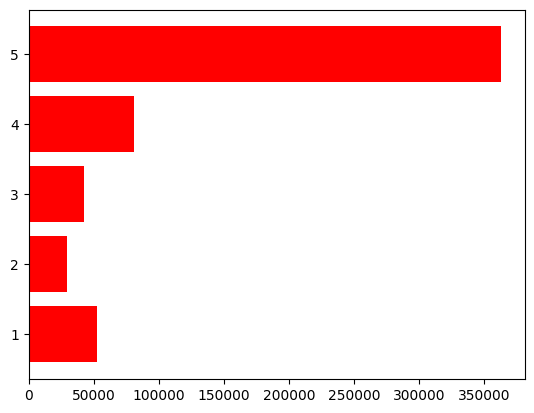

In [9]:
create_graphic_classes()

--> Las clases están balanceadas.

## Cantidad de oraciones por rangos (bins) de length:
Con el objetivo de ver la cantidad de oraciones por rango de length, creé un gráfico en bins.
- El eje 'y' representa la cantidad de oraciones que existe en ese bin de length.
- Escala logarítmica (en base 10) para que cantidad de oraciones pequeñas no se desvanezcan.

In [8]:
def create_histogram_palabras_bin(cant_pal_lista):
    plt.figure(figsize=(15,8))
    plt.hist(cant_pal_lista,bins=100,edgecolor="black",log=True)
    plt.xlabel("Bins (agrupaciones por cantidad de palabras (length))")
    plt.ylabel("Cantidad de oraciones por length (agrupados en bins)")
    plt.show()

    pass

In [9]:
cant_pal_orac=[len(dataset_df["Text"][idx].split()) for (idx,review) in enumerate(dataset_df["Text"])]

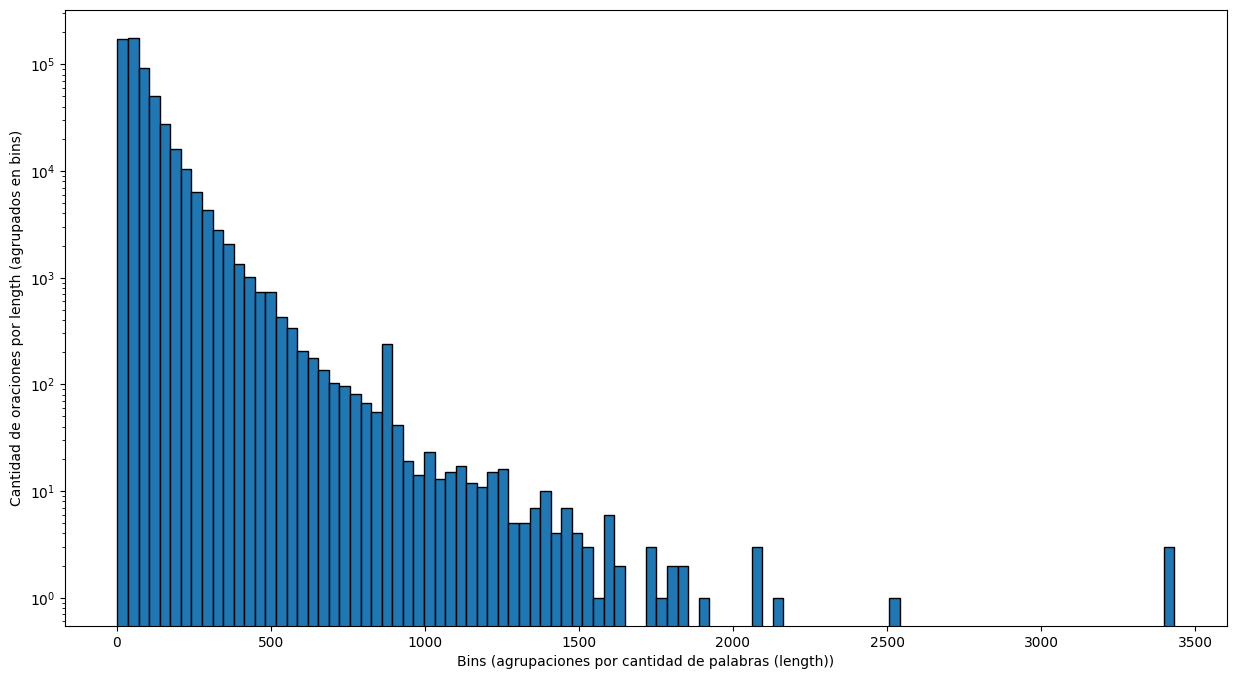

In [10]:
create_histogram_palabras_bin(cant_pal_orac)

--> De aquí, se puede ver que
- En el bin [2000 - 2500] (rango de cantidad de palabras), existen, aproximadamente, menos de 10 oraciones.
- Es decir, son menos de 10 oraciones las que tienen una cantidad de palabras en el rango [2000 - 2500].

--> De la gráfica, también se deduce que hay mayor presencia de oraciones con 100 a 800 palabras.

----

## Resumen estadístico

In [39]:
print("====")
print(f"1) Cantidad de clases: {dataset_df["Score"].value_counts()}")
print("====")
print(f"2) Promedio de palabras por oración: {dataset_df["Text"].str.split().str.len().mean()}")
print("====")
print(f"3) Cantidad mínima de palabras en una oración: {min(dataset_df["Text"].str.split().str.len())}")
print("====")
print(f"4) Cantidad máxima de palabras en una oración: {max(dataset_df["Text"].str.split().str.len())}")

====
1) Cantidad de clases: Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64
====
2) Promedio de palabras por oración: 80.26402312236347
====
3) Cantidad mínima de palabras en una oración: 3
====
4) Cantidad máxima de palabras en una oración: 3432


----

# 2) Text Processing

# Sampleo de un texto

A continuación, sampleo una oración para verificar si contiene fragmentos de etiquetas HTML, dígitos (relevantes o no), caracteres especiales, etc.

In [57]:
random_review=dataset_df.loc[11407,'Text'] #100

In [58]:
print(f"Length, random review: {len(random_review.split())}")
print(f"HTML elements: {'<br' in random_review}")
print(f"Dígitos (1 o más dígitos): {bool(re.search(r"\d+",random_review))}")
print(f"Caracteres especiales (distintos de letras, números, espacios): {bool(re.search(r"[^a-zA-Z0-9\s]",random_review))}")

Length, random review: 41
HTML elements: True
Dígitos (1 o más dígitos): True
Caracteres especiales (distintos de letras, números, espacios): True


In [59]:
random_review

'These apricots are just great.  They are full of flavor but not too sweet.  There are about 8 to 9 halves to a can.<br /><br />There was a problem with some severely dented cans but as usual, Amazon made it right.'

## 2.0) Eliminar las oraciones con más de 900 palabras
- Luego de ver la cantidad de oraciones a eliminarse, y que no afectan significativamente a las clases minoritarias, se procede a removerlas.

In [6]:
#Dataset de las oraciones con longitud >= 900
data_900=dataset_df[dataset_df["Text"].str.split().str.len()>=900]

In [7]:
#De las 255 oraciones, cuántas de cada "score" existen
print(f"Oraciones a eliminarse: {data_900.shape[0]}")
print(data_900["Score"].value_counts())

Oraciones a eliminarse: 255
Score
5    138
4     45
1     28
2     24
3     20
Name: count, dtype: int64


In [8]:
#Al NO afectar significativamente a las clases minoritarias, se procede con la eliminación de dichas oraciones
data_final=dataset_df.drop(dataset_df[dataset_df["Text"].str.split().str.len()>=900].index,axis=0)

In [9]:
#Cantidad de filas final (luego de eliminar las 255 oraciones):
print(f"Cantidad de oraciones inicial: {dataset_df.shape[0]}. Cantidad de oraciones final: {data_final.shape[0]}")

Cantidad de oraciones inicial: 568454. Cantidad de oraciones final: 568199


**--> Quitar dichas oraciones, no mejora la predicción en la clase 1 ("neutral"). Por ello, se probó con Tf-Idf n-grams**

# Cleaning text
- El cleaning text trataré de realizarlo en el dataframe para evitar cargar todo en memoria.
- Para ello, crearé una columna nueva donde estará el preprocesamiento.

## 2.1) Lower case (ML y DL)

In [10]:
data_final["prep_text"]=data_final["Text"].map(lambda review: review.lower()) #dataset_df

## 2.2) Remover HTML (ML y DL)

In [11]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub('<.*?>',"",review))

In [12]:
data_final.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,prep_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy at a great price. there was a wid...


## 2.3) Contractions (ML y DL)
- Reemplazo las contracciones por las palabras no abreviadas

a) Enfoque inicial para reemplazar las palabras con 'nt que no necesariamente se desglosan en 'palabra' + 'not'

In [13]:
contractions_dict={
    "don't": "do not",
    "won't": "will not",
    "can't": "cannot",
    "shan't":"shall not",
    "should've": "should have",
    "it's": "it is","he's":"he is","she's":"she is",
    "i'm": "i am","you're": "you are","we're":"we are","they're":"they are"
}

In [14]:
lambda_contraction=lambda oracion: " ".join([contractions_dict.get(word,word) for word in oracion.split()])

In [15]:
data_final["prep_text"]=data_final["prep_text"].map(lambda_contraction)

b) Regular expresion para detectar el patrón word'nt --> word + not

In [16]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub(r"(\w+)n't",r"\1 not",review))

## 2.4) Posesivos (ML y DL)
- Sujeto+'s --> Sujeto
- Se elimina el 's

In [17]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub(r"(\w+)'s",r"\1",review))

## 2.5) Signos de puntuación repetidos (DL solo, ML utiliza el tokenizer de TF-IDF)
- Signos de puntuación permitidos: ! ? , .

In [18]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub(r"([!?,.])\1+",r"\1",review)) #!?,.

## 2.6) Eliminar caracteres distintos de letras y signos de puntuación permitidos (SÍ DL, NO ML porque utiliza el tokenizer de TF-IDF)
- Elimino caracteres distintos a los signos de puntuación permitidos
- Opcional: Probar un modelo donde remuevo todos los caracteres distintos de letras: r"[^\w\s]

In [19]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub(r"[^a-zA-Z0-9\s!?,.]","",review)) #!?,.

## 2.7) Mantener dígitos (evitando números grandes con , o .)
- Evaluar si eliminar: algunos números representan el rating --> manejar esto


### DL Enfoque:

In [21]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub(r'\d[\d,]*\.?\d*',' NUM ', review))

### ML Enfoque:

In [22]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub(r" \d+", "", review))

## 2.8) Manejar repeticiones de palabras (ML Y DL)
- En el texto se tienen palabras como 'aaaaand', lo que puede generar más tokens y añadir ruido.
- Entonces, la función se encarga de eliminar las repeticiones: "aaaaaand" a "and"

In [22]:
data_final["prep_text"]=data_final["prep_text"].map(lambda review: re.sub(r"(.)\1{2,}", r"\1\1", review))

## 2.9) Stop words (SÍ DL, EVALUAR ML)

In [ ]:
#Descargo y obtengo las stopwords
nltk.download("stopwords")

In [24]:
#Obtengo las palabras 'stop words' (en una lista)
stop_words=stopwords.words("english")

In [25]:
#Palabras que NO debo remover, ya que son importantes para la tarea
not_remove_words=["no", "nor", "not", "few", "more", "most", "too", "very", "will", "might", "need", "would",
                  "did", "do", "had","has", "have", "was","were" "is","are", "shall", "could", "must", "should",
                  "but"]  #but, while agregados, IMPORTANTE

In [26]:
#Lista final de stop words
stop_words_final=[word for word in stop_words if word not in not_remove_words]

In [27]:
#Función para quedarse solo con las palabras que NO son stop words
s_w_function=lambda oracion: " ".join([word for word in oracion.split() if word not in stop_words_final]) 

In [28]:
#Aplico la función al dataset
data_final["prep_text"]=data_final["prep_text"].map(s_w_function)

## 2.10) Stemming / Lemmatization: Opcional
- Ver si es necesario y si mejora (o no) el rendimiento del modelo

## 2.11) Reemplazando las clases categóricas por númericas para que empiecen desde cero --> Útil para entrenar al modelo
- En este dataset es necesario que los Scores (Labels) empiecen desde 0 (no desde 1) para la predicción del modelo: 
  - [0 - 1] -->  Bad
  - [2] --> Neutral
  - [3 - 4] --> Good

In [29]:
data_final["prep_score"]=data_final["Score"].replace({1:0,2:0,3:1,4:2,5:2})

In [30]:
data_final.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,prep_text,prep_score
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,have bought several vitality canned dog food p...,2
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanuts.t...,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,"confection has around few centuries. light, pi...",2
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,are looking secret ingredient robitussin belie...,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy great price. was wide assortment y...,2


-----

# 3) Train - Valid - Test Split

- Train, Valid

In [31]:
x_train,x_valid,y_train,y_valid=train_test_split(data_final["prep_text"],data_final["prep_score"],test_size=0.2,random_state=42)

* Valid, Test

In [32]:
x_valid_final,x_test_final,y_valid_final,y_test_final=train_test_split(x_valid,y_valid,test_size=0.2,random_state=42)

-----

# 3.1) Distribución de clases luego de dividir el dataset en Train, Valid, Test

In [28]:
print(f"Clases Train: {y_train.value_counts()}")
print("#=====#")
print(f"Clases Valid: {y_valid_final.value_counts()}")
print("#=====#")
print(f"Clases Test: {y_test_final.value_counts()}")

Clases Train: prep_score
2    354752
0     65856
1     34155
Name: count, dtype: int64
#=====#
Clases Valid: prep_score
2    71295
0    12894
1     6763
Name: count, dtype: int64
#=====#
Clases Test: prep_score
2    17730
0     3287
1     1722
Name: count, dtype: int64


In [30]:
x_valid_final.shape,y_valid_final.shape    #x_valid.head(),y_valid.head()

((90952,), (90952,))

In [48]:
x_test_final.shape,y_test_final.shape

((22739,), (22739,))

----

# 3.2) Imbalance de clases

In [33]:
class_weight=compute_class_weight(class_weight="balanced",classes=np.array([0,1,2]),y=np.array(y_train)) #classes=np.array([0,1,2,3,4])

In [34]:
class_weight_tensor=torch.tensor(class_weight,dtype=torch.float32)

In [35]:
class_weight_tensor

tensor([2.3113, 4.4386, 0.4270])

----

# MÉTRICAS: FUNCIONES DE EVALUACIÓN

In [36]:
def conf_matrix(y_true,y_preds):
    c_m=confusion_matrix(y_true,y_preds)
    c_m_display=ConfusionMatrixDisplay(c_m)
    c_m_display.plot()

In [37]:
def metrics(y_true,y_preds):
    accuracy=accuracy_score(y_true,y_preds)
    f1=f1_score(y_true,y_preds,average="macro")
    precision=precision_score(y_true,y_preds,average="macro")
    recall=recall_score(y_true,y_preds,average="macro")

    print(f"Accuracy: {accuracy}")
    print(f"F1 Score: {f1}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")

In [38]:
def report(y_true,y_preds):
    target_names=["Clase 0","Clase 1","Clase 2"]
    print(classification_report(y_true,y_preds,target_names=target_names))

-----

# ENTRENAMIENTO

# - MACHINE LEARNING ENFOQUE:

### - TF-IDF: Text into vectors

In [31]:
#Tf Idf para convertir el texto en vectores
tf_idf=TfidfVectorizer(strip_accents="ascii",ngram_range=(2,3)) #analyzer="word",stop_words=stop_words_final   ngram_range=(1,2)

In [32]:
#Fit-transform
x_train_vectorized=tf_idf.fit_transform(x_train)
x_valid_vectorized=tf_idf.transform(x_valid)

In [33]:
#Transformar a numpy array y_train
y_train_array=np.array(y_train)

In [34]:
#Class weight para los modelos ML
dict_class_weight={i:weight.item() for i,weight in enumerate(class_weight)}

### - Modelo: Logistic Regression: Train

In [35]:
log_reg=LogisticRegression(class_weight=dict_class_weight,max_iter=1000) #1000

In [ ]:
log_reg.fit(x_train_vectorized,y_train_array)

### - Validation set
- Predicciones con el modelo

In [37]:
#Realizar la predicción
preds_valid=log_reg.predict(x_valid_vectorized)

### - Métricas

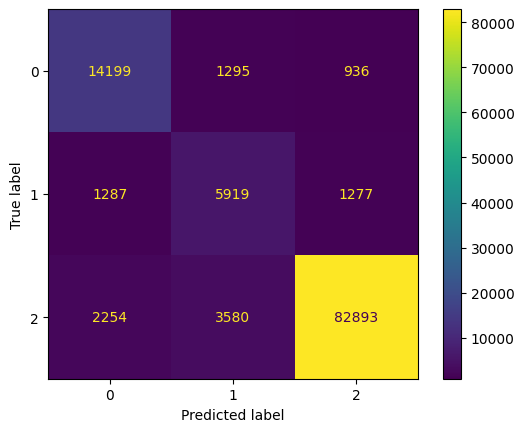

In [38]:
#Confusion Matrix
conf_matrix(y_valid,preds_valid)

In [43]:
#Métricas
metrics(y_valid,preds_valid)
print(f"====")
report(y_valid,preds_valid)

Accuracy: 0.906467793030623
F1 Score: 0.7996293477555853
Precision: 0.7742506405329449
Recall: 0.8320693314779387
====
              precision    recall  f1-score   support

     Clase 0       0.80      0.86      0.83     16430
     Clase 1       0.55      0.70      0.61      8483
     Clase 2       0.97      0.93      0.95     88727

    accuracy                           0.91    113640
   macro avg       0.77      0.83      0.80    113640
weighted avg       0.92      0.91      0.91    113640



### - Guardar Tf-Idf y Logistic Regression model

In [40]:
print("¿TF-IDF fitteado correctamente?:", hasattr(tf_idf, "idf_"))
print("¿Regresión Logística fitteada?:", hasattr(log_reg, "classes_"))

¿TF-IDF fitteado correctamente?: True
¿Regresión Logística fitteada?: True


In [41]:
joblib.dump(tf_idf,"tfidf_uni_bi_tri_grams_modelo_final.joblib")

['tfidf_uni_bi_tri_grams_modelo_final.joblib']

In [42]:
joblib.dump(log_reg,"logreg_uni_bi_tri_grams_modelo_final.joblib")

['logreg_uni_bi_tri_grams_modelo_final.joblib']

-------

# - DEEP LEARNING ENFOQUE:

### 4.1) Crear el vocabulario y mapearlo a un índice
### - Tokenization: Word level
        - word_tokenizer de nltk
### - Vocabulario: word --> index

In [126]:
#Función que crea el vocabulario y los mapea a un token
def create_vocab_map(dataframe,tokenizer):
    vocab_map={'PAD':0,'UNK':1}     #--> Con esto me aseguro que estos id queden reservados y colocar id_padding=0 en el entrenamiento
    
    for row_review in dataframe:
        for word in tokenizer(row_review):
            if word not in vocab_map:
                vocab_map[word]=len(vocab_map)

    return vocab_map

In [127]:
vocab=create_vocab_map(x_train,word_tokenize)

In [128]:
vocab_length_word_token=len(vocab)

In [129]:
len(vocab)

263109

### 4.2) Tokenizador SentencePiece Unigram
- 1). Convertir "x_train" en un archivo txt para entrenar el tokenizer.
- 2). Entrenamiento del tokenizador
- 3). Cargar el tokenizador y convertir a ID tokens

In [36]:
#1) Conversión a txt
name_txt="x_train_txt.txt"
x_train.to_csv(name_txt,index=False,header=False)

In [ ]:
#2) Entrenamiento del tokenizador
path_txt="ruta_donde_se_almaceno_el_dataset_convertido_a_txt"
tokenizer=smp.SentencePieceTrainer

tokenizer.train(
    input=path_txt,
    model_prefix="unigram_model",
    vocab_size=8000,
    model_type='unigram'
)

In [ ]:
#3) Cargar el tokenizador
path_tokenizer="ruta_donde_se_guardo_el_archivo_model_del_tokenizador"

tokenizer_model=smp.SentencePieceProcessor()
tokenizer_model.load(path_tokenizer)

In [ ]:
#4) Probar el tokenizador
tokenizer_model.encode("this is a test review",out_type=int)

In [ ]:
tokenizer_model.unk_id()

----

# 5) Creación del custom Dataset

In [42]:
class Dataset(Dataset):
    def __init__(self,tokenizer,x,y,use_sp:bool,vocab=None):
        self.vocab=vocab           #Diccionario --> Vocabulario
        self.tokenizer=tokenizer   #Tokenizer
        self.x,self.y=x,y          #x,y
        self.use_sp_tokenizer=use_sp

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self,idx):
        x_act,y_act=self.x.iloc[idx],self.y.iloc[idx]          #x_act, y_act (review preprocesada,label)
        
        
        #Si NO se usa Sentence Piece --> Tokenizador a nivel de palabra
        if not self.use_sp_tokenizer:
            x_act_tokenized=self.tokenizer(x_act)                  #[token1,token2,token3,token4,...] --> lista de tokens
            
            x_act_tensor=torch.tensor([self.vocab[token] if token in self.vocab else self.vocab['UNK'] for token in x_act_tokenized])  #torch.tensor([vocab[token] for token in x_act_tokenized])
            y_act_tensor=torch.tensor(y_act)

        #Sí se usa Sentence Piece
        else:
            x_act_tensor=torch.tensor(self.tokenizer.encode(x_act,out_type=int))
            y_act_tensor=torch.tensor(y_act)
        
        return x_act_tensor,y_act_tensor

In [43]:
#Instancio el dataset de train
dataset_final_train=Dataset(tokenizer_model,x_train,y_train,True)

In [43]:
dataset_final_train[0]

(tensor([  15,   96,  343,   13,  243,    4,  662,   20,    4,    5,   10, 1023,
          662,   20,    3,   19,    5,   49,   12]),
 tensor(0))

In [44]:
#Instancio el dataset de valid
dataset_final_valid=Dataset(tokenizer_model,x_valid_final,y_valid_final,True)

In [45]:
#Instancio el dataset de test
dataset_final_test=Dataset(tokenizer_model,x_test_final,y_test_final,True)

----

# 6) Creación del Data Loader

In [46]:
#Función para el añadir padding (id=0) y permitir el training por batches
def collate_fn(batch):
    
    x,y=zip(*batch)
    
    
    length_batch_review=[len(review) for review in x]     #No está ordenado --> La longitud DEPENDE de la secuencia, MAS NO de sus elementos internos :D Lo que es CORRECTO para evitar errores como NO procesar el unk id = 0 de SentencePiece. Ver el colab PaddingYSentencePieceYPytorchTraining
    
    length_max=max(length_batch_review) #Se obtiene el length máximo
    
    
    x_final_tensor=torch.zeros(size=(len(x),length_max),dtype=torch.int32)
    y_final_tensor=torch.zeros(size=(len(x),1),dtype=torch.float32)
    
    for idx,tensor in enumerate(x):
        
        zero_padding_tensor=torch.zeros(length_max-len(x[idx]),dtype=torch.int32)
        
        tensor_final=torch.cat([tensor,zero_padding_tensor],dim=0) #POST PADDING
        
        x_final_tensor[idx]=tensor_final
        y_final_tensor[idx]=y[idx]
        
      
    return x_final_tensor,y_final_tensor,length_batch_review

In [47]:
dataloader_train=DataLoader(dataset=dataset_final_train,batch_size=128,collate_fn=collate_fn,shuffle=False)

In [48]:
dataloader_valid=DataLoader(dataset=dataset_final_valid,batch_size=64,collate_fn=collate_fn,shuffle=False)

In [49]:
dataloader_test=DataLoader(dataset=dataset_final_test,batch_size=64,collate_fn=collate_fn,shuffle=False)

In [50]:
for idx,(x,y,length_batch) in enumerate(dataloader_train):
    print("===")
    print(f"x: {x.shape}")
    print(f"y: {y.shape}")
    break

===
x: torch.Size([128, 210])
y: torch.Size([128, 1])


In [51]:
for idx,(x,y,length_batch) in enumerate(dataloader_test):
    print("====")
    print(f"x: {x.shape}")
    print(f"y: {y.shape}")
    break

====
x: torch.Size([64, 499])
y: torch.Size([64, 1])


-----

# 7) Arquitectura del modelo

### Modelo NO Attention

### - LSTM+GlobalMaxPooling

In [75]:
class ModeloLSTM(torch.nn.Module):
    def __init__(self,len_vocab,num_clases,emb_dim,hidden_size,num_layers,out_l1_dim,out_l2_dim,bidirectional:bool):
        super().__init__()
        self.num_emb=len_vocab
        self.bid=2 if bidirectional else 1
        
        self.embedding_layer=torch.nn.Embedding(num_embeddings=self.num_emb,embedding_dim=emb_dim,padding_idx=0)
        
        self.lstm=torch.nn.LSTM(input_size=emb_dim,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,bidirectional=bidirectional)
        
        self.ln1=torch.nn.Linear(in_features=hidden_size*self.bid,out_features=out_l1_dim)
        self.ln2=torch.nn.Linear(in_features=out_l1_dim,out_features=out_l2_dim)
        self.ln3=torch.nn.Linear(in_features=out_l2_dim,out_features=num_clases) 
        self.relu=torch.nn.ReLU()
        
        self.dropout=torch.nn.Dropout(p=0.1)
        self.layer_norm_1=torch.nn.LayerNorm(out_l1_dim)
        self.layer_norm_2=torch.nn.LayerNorm(out_l2_dim)

    def forward(self,data,length_batch):
        x=self.embedding_layer(data) #[num_batch,seq_length,embedding_dim]
        

        padded_sequence=pack_padded_sequence(input=x,lengths=length_batch,batch_first=True,enforce_sorted=False)
        
        
        #LSTM
        hidden_states_no_padding,(final_hidden_state_real,final_cell_state)=self.lstm(padded_sequence)
        

        #GlobalMaxPooling: A lo largo de TODOS los sequences, se obtiene el mayor valor en cada dimensión obtenido de cada sequence
        #--> [batch_size,seq_length,hidden_size]
        hidden_states_padding,_=pad_packed_sequence(sequence=hidden_states_no_padding,batch_first=True)  #--> [N,L,D*Hout], [:,:,:mitad] forward, [:,:,mitad:] backward en 't'
        
        x_rsh,indexes=torch.max(hidden_states_padding,dim=1) #[batch_size,hidden_state]
        

        x=self.relu(self.dropout(self.layer_norm_1(self.ln1(x_rsh))))
        x=self.relu(self.dropout(self.layer_norm_2(self.ln2(x))))
        x=self.ln3(x)
        
        return x

### - GRU + GlobalMaxPooling

In [ ]:
class ModeloGRU(torch.nn.Module):
    def __init__(self,len_vocab,num_clases,emb_dim,hidden_size,num_layers,out_l1_dim,out_l2_dim,bidirectional:bool):
        super().__init__()
        self.num_emb=len_vocab
        self.bid=2 if bidirectional else 1
        
        self.embedding_layer=torch.nn.Embedding(num_embeddings=self.num_emb,embedding_dim=emb_dim,padding_idx=0)
        
        self.gru=torch.nn.GRU(input_size=emb_dim,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,bidirectional=bidirectional)
        
        self.ln1=torch.nn.Linear(in_features=hidden_size*self.bid,out_features=out_l1_dim)
        self.ln2=torch.nn.Linear(in_features=out_l1_dim,out_features=out_l2_dim)
        self.ln3=torch.nn.Linear(in_features=out_l2_dim,out_features=num_clases) 
        self.relu=torch.nn.ReLU()
        
        self.dropout=torch.nn.Dropout(p=0.1)
        self.layer_norm_1=torch.nn.LayerNorm(out_l1_dim)
        self.layer_norm_2=torch.nn.LayerNorm(out_l2_dim)

    def forward(self,data,length_batch):
        x=self.embedding_layer(data) #[num_batch,seq_length,embedding_dim]
        

        padded_sequence=pack_padded_sequence(input=x,lengths=length_batch,batch_first=True,enforce_sorted=False)
        
        
        #GRU
        hidden_states_no_padding,final_hidden_state_real=self.gru(padded_sequence)
        

        #GlobalMaxPooling: A lo largo de TODOS los sequences, se obtiene el mayor valor en cada dimensión obtenido de cada sequence
        #--> [batch_size,seq_length,hidden_size]
        hidden_states_padding,_=pad_packed_sequence(sequence=hidden_states_no_padding,batch_first=True)  #--> [N,L,D*Hout], [:,:,:mitad] forward, [:,:,mitad:] backward en 't'
        
        x_rsh,indexes=torch.max(hidden_states_padding,dim=1) #[batch_size,hidden_state]
        

        x=self.relu(self.dropout(self.layer_norm_1(self.ln1(x_rsh))))
        x=self.relu(self.dropout(self.layer_norm_2(self.ln2(x))))
        x=self.ln3(x)
        
        return x

### Modelo Attention

In [99]:
class Attention(torch.nn.Module):
    def __init__(self,bidirectional,hidden_size_model,context_vector_size):
        super().__init__()
        self.bidirectional=bidirectional
        
        self.U=torch.nn.Linear(in_features=hidden_size_model*bidirectional,out_features=context_vector_size)
        self.V=torch.nn.Linear(in_features=context_vector_size,out_features=1)

        self.tanh=torch.nn.Tanh()
        self.softmax=torch.nn.Softmax(dim=1)

    def forward(self,query,keys,batch_lengths):
        #Máscaras
        mask=torch.arange(keys.size(1),device=keys.device).unsqueeze(0)
        mask=mask.expand(keys.size(0),keys.size(1))
        value_masks=mask<torch.tensor(batch_lengths,device=keys.device).unsqueeze(1)
        
        
        
        #Key vectors: [batch_size,seq_length,D*h_out], D:bidirectional or not
        #--> "will contain a concatenation of the forward and reverse hidden states at each time step in the sequence (PyTorch Source)"
        keys_vector=self.U(keys)    #--> AT EATCH time step, forward and reverse hidden states
        


        #Tanh activation function
        tanh=self.tanh(keys_vector) #Cuando NO hay query,  #[batch_size,seq_length,context_vector_size]
       
        

        #Weights attention scores de cada HIDDEN STATE
        v=self.V(tanh).squeeze(2)                                #[batch_size,sequence_length,1] --> [batch_size,sequence_length]
        v_masked=v.masked_fill(~value_masks.to(device),-1e9)     #[batch_size,sequence_length]
        weights_attention=self.softmax(v_masked).unsqueeze(1)    #[batch_size,1,sequence_length]
        
              
        context_vector=torch.bmm(weights_attention,keys)    #--> weights_attention [batch_size,1,sequence_length]*keys [batch_size,sequence_length,D*Hout]                                                                   #--> context_vector: [batch_size,1,D*Hout]
        context_vector_final=context_vector.squeeze(1)   #--> context_vector_final: [batch_size,D*Hout]
        
        
        return context_vector_final

In [100]:
class Modelo_Attention(torch.nn.Module):
    def __init__(self,len_vocab,num_clases,emb_dim,hidden_size,context_vector_attn_size,num_layers,out_l1_dim,out_l2_dim,bidirectional:bool):
        super().__init__()
        self.num_emb=len_vocab
        self.bid=2 if bidirectional else 1
        self.embedding_layer=torch.nn.Embedding(num_embeddings=self.num_emb,embedding_dim=emb_dim) #padding_idx=0
        
        self.gru=torch.nn.GRU(input_size=emb_dim,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,bidirectional=bidirectional)
        
        self.ln1=torch.nn.Linear(in_features=hidden_size*self.bid,out_features=out_l1_dim)
        self.ln2=torch.nn.Linear(in_features=out_l1_dim,out_features=out_l2_dim)
        self.ln3=torch.nn.Linear(in_features=out_l2_dim,out_features=num_clases)
        self.relu=torch.nn.ReLU()
        
        self.dropout=torch.nn.Dropout(p=0.1)
        self.layer_norm1=torch.nn.LayerNorm(out_l1_dim)
        self.layer_norm2=torch.nn.LayerNorm(out_l2_dim)
        
        self.attention=Attention(bidirectional=self.bid,hidden_size_model=hidden_size,context_vector_size=context_vector_attn_size)

    
    def forward(self,data,length_batch):
        x=self.embedding_layer(data) #[num_batch,seq_length,embedding_dim]

        padded_sequence=pack_padded_sequence(input=x,lengths=length_batch,batch_first=True,enforce_sorted=False) ##-->> OJITO
        
        
        #GRU                                                        
        hidden_states_no_padding,final_hidden_state_real=self.gru(padded_sequence) #[num_batch,time_steps,emb_dim],[D*num_layers,batch_size,hidden_size], D:2 if bidirectional, else 1
        
        
        #Pad Packed Sequence para los hidden states y el attention mechanism
        hidden_states_padding,_=pad_packed_sequence(sequence=hidden_states_no_padding,batch_first=True)
        
        
        #Attention
        batch_context_vectors=self.attention(query=final_hidden_state_real,keys=hidden_states_padding,batch_lengths=length_batch)


        #Linear layers
        x=self.relu(self.dropout(self.layer_norm1(self.ln1(batch_context_vectors))))
        x=self.relu(self.dropout(self.layer_norm2(self.ln2(x))))
        x=self.ln3(x)
        
        return x

# 8) Entrenamiento

### Hiperparámetros: Sí ATTENTION

In [104]:
#Hiperparámetros
epocas=100
learning_rate=1e-5
mod=Modelo_Attention(len_vocab=8000,num_clases=3,emb_dim=300,hidden_size=256,context_vector_attn_size=128,num_layers=2,out_l1_dim=128,out_l2_dim=64,bidirectional=False).to(device)
optim=torch.optim.Adam(params=mod.parameters(),lr=learning_rate)
loss=torch.nn.CrossEntropyLoss(weight=class_weight_tensor.to(device))
earle_stopping_steps=5

### Hiperparámetros: No ATTENTION

In [76]:
#Hiperparámetros
epocas=100
learning_rate=1e-5
mod=ModeloGRU(len_vocab=8000,num_clases=3,emb_dim=300,hidden_size=256,num_layers=2,out_l1_dim=128,out_l2_dim=64,bidirectional=False).to(device) #64,32
optim=torch.optim.Adam(params=mod.parameters(),lr=learning_rate)
loss=torch.nn.CrossEntropyLoss(weight=class_weight_tensor.to(device)) 
early_stopping_steps=5

### Entrenamiento

In [ ]:
loss_plotteo_train=[]
loss_plotteo_valid=[]
valid_base_early_stop=float("inf")

for epoca in range(epocas):
    loss_epoca_train=0
    loss_epoca_valid=0


    #Entrenamiento
    mod.train()
    for idx,(x_train_batch,y_train_batch,batch_length_train) in enumerate(dataloader_train):
        preds_train=mod(x_train_batch.to(device),batch_length_train) 
        
        
        error_train=loss(preds_train,y_train_batch.squeeze(1).long().to(device)) #Calculo el error 
        
        
        optim.zero_grad() #Reset de gradientes, para evitar la acumulación
        
        error_train.backward()  #Cálculo de gradientes a partir del error, con respecto a los pesos del modelo
        optim.step() #Actualizo los pesos

        loss_epoca_train+=error_train.item() #Añado el error: .item() --> Para NO guardar la variable que mapea el grafo autograd
        
    loss_train_value=loss_epoca_train/(idx+1)
    loss_plotteo_train.append(loss_train_value)

    #Validación: no se calculan los gradientes aquí
    mod.eval()
    with torch.no_grad():
        for idx,(x_valid_batch,y_valid_batch,batch_length_valid) in enumerate(dataloader_valid):
            preds_valid=mod(x_valid_batch.to(device),batch_length_valid) #predicciones en el validation set

            error_valid=loss(preds_valid,y_valid_batch.squeeze(1).long().to(device)) #cálculo del error en el validation set

            loss_epoca_valid+=error_valid.item() #Añado el error, .item() --> Para NO guardar la variable que mapea el grafo autograd
            
        loss_valid_value=loss_epoca_valid/(idx+1)   
        loss_plotteo_valid.append(loss_valid_value)

    
    print(f"Época {epoca}--> Train Loss: {loss_train_value}. Val Loss: {loss_valid_value}")

    
    #Early Stopping
    
    #Si el loss actual es menor al anterior
    if loss_valid_value<valid_base_early_stop:
        torch.save(mod.state_dict(),f"/carpeta_donde_guardar_el_modelo/modelo.pth")    #Guardo el modelo (Colocar la ruta donde se guardará el modelo)
            
        valid_base_early_stop=loss_valid_value                        #Actualizo el valor
        early_stopping_step_actual=0                                   #Step actual, Early Stopping

    #Si es mayor, entonces se empieza a contar los steps del early stopping
    else:
        early_stopping_step_actual+=1                                  #Actualizo el step actual
        print(f"El modelo no está mejorando {early_stopping_step_actual} veces")

        #Si llega a la cantidad de steps permitidos, se termina el entrenamiento, guardando solo el mejor modelo
        if early_stopping_step_actual==5:
            break

----

# 8) Cargo los pesos del modelo y los instancio

### Sí ATTENTION

In [106]:
#Instancio el modelo
modelo_actual=Modelo_Attention(len_vocab=8000,num_clases=3,emb_dim=300,hidden_size=256,context_vector_attn_size=128,num_layers=2,out_l1_dim=128,out_l2_dim=64,bidirectional=False).to(device)

### No attention

In [78]:
#Instancio el modelo
modelo_actual=ModeloGRU(len_vocab=8000,num_clases=3,emb_dim=300,hidden_size=256,num_layers=2,out_l1_dim=128,out_l2_dim=64,bidirectional=False).to(device)

### Cargar los pesos

In [107]:
#Cargo los pesos
path_weights_modelo="Colocar_El_Path_Donde_Se_Guardo_Los_Pesos_Del_Modelo"                          
weights_modelo=torch.load(path_weights_modelo,weights_only=True)

In [108]:
#Al modelo instancio, le coloco los pesos aprendidos cargados anteriormente
modelo_actual.load_state_dict(weights_modelo)

<All keys matched successfully>

# 9) Plotteo del Loss: Train / Validation

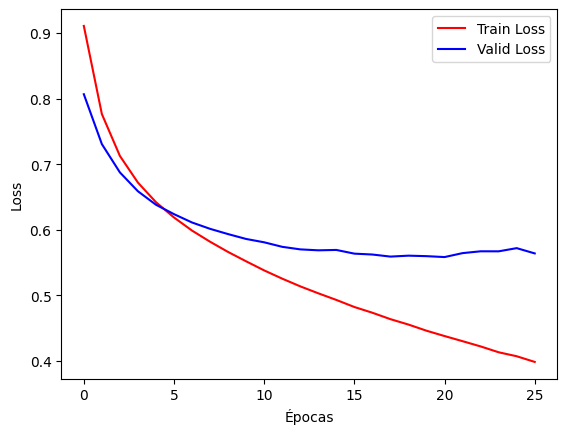

In [109]:
plt.plot(range(len(loss_plotteo_train)),loss_plotteo_train,color="red",label="Train Loss")
plt.plot(range(len(loss_plotteo_valid)),loss_plotteo_valid,color="blue",label="Valid Loss")
plt.xlabel("Épocas"),plt.ylabel("Loss")
plt.legend()
plt.show()

----

# 10) Métricas

- Función para obtener las predicciones y labels

In [82]:
def evaluate_model(model,data):
    model.eval()
    y_preds,y_real=[],[]
    with torch.no_grad():
        for idx,(x,y,length_data_batch) in enumerate(data):     
            preds=model(x.to(device),length_data_batch)
            y_preds.append(preds)
            y_real.append(y)

    #Numpy arrays
    y_preds_final,y_real_final=torch.argmax(torch.cat(y_preds,dim=0).squeeze(1).cpu(),dim=1).numpy(),torch.cat(y_real,dim=0).squeeze(1).cpu().numpy()

    
    print(f"y preds final: {y_preds_final.shape}, dtype: {y_preds_final.dtype}")
    print(f"y rela final: {y_real_final.shape}, dtype: {y_real_final.dtype}")
    
    return y_preds_final,y_real_final

In [113]:
#Obtengo las predicciones y labels
y_preds,y_reales=evaluate_model(modelo_actual,dataloader_valid) #(n_shape,)

y preds final: (90952,), dtype: int64
y rela final: (90952,), dtype: float32


In [114]:
y_preds[:5],y_reales[:5]

(array([2, 2, 1, 2, 2]), array([2., 2., 1., 2., 2.], dtype=float32))

### Confusion Matrix

In [116]:
#Confusion matrix
c_m=confusion_matrix(y_reales,y_preds)

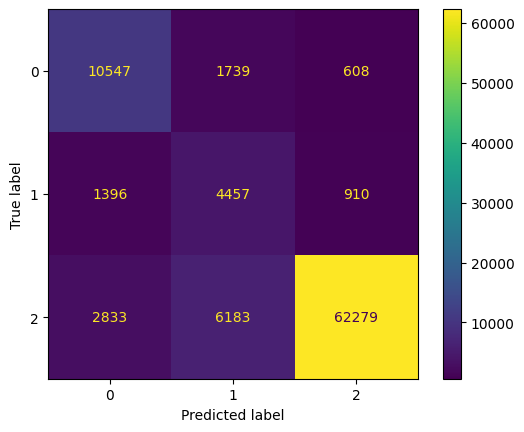

In [117]:
#Display de la confusion matrix
disp=ConfusionMatrixDisplay(confusion_matrix=c_m)
disp.plot()

### Accuracy

In [118]:
accuracy=accuracy_score(y_reales,y_preds)
print(f"Accuracy: {accuracy}")

Accuracy: 0.849711935966224


### F1 Score

In [119]:
f1_score_value=f1_score(y_reales,y_preds,average="macro")
print(f"F1 Score: {f1_score_value}")

F1 Score: 0.7166809880254469


### Precision

In [120]:
precision=precision_score(y_reales,y_preds,average="macro")
print(f"Precision: {precision}")

Precision: 0.6833478841040738


### Recall

In [121]:
recall=recall_score(y_reales,y_preds,average="macro")
print(f"Recall: {recall}")

Recall: 0.7835146439019343


In [122]:
report(y_reales,y_preds)

              precision    recall  f1-score   support

     Clase 0       0.71      0.82      0.76     12894
     Clase 1       0.36      0.66      0.47      6763
     Clase 2       0.98      0.87      0.92     71295

    accuracy                           0.85     90952
   macro avg       0.68      0.78      0.72     90952
weighted avg       0.89      0.85      0.87     90952



----

# 11) Almacenar las losses y métricas en un archivo JSON para gráficas posteriores
- Estas métricas son de validación

In [123]:
losses_and_metrics={
    "loss_train": loss_plotteo_train,
    "loss_valid":loss_plotteo_valid,
    "accuracy":accuracy,
    "f1_score":f1_score_value,
    "precision":precision,
    "recall":recall
}

In [124]:
with open("/ruta_para_guardar_las_metricas/metricas.json","w") as f: 
    json.dump(losses_and_metrics,f,indent=5)


----

# 12) Evaluación

### MACHINE LEARNING

In [43]:
#Funciones auxiliares
def load_ml_model(tf_idf_path,log_reg_path):
    vectorizer_tf_idf=joblib.load(tf_idf_path)
    log_reg=joblib.load(log_reg_path)
    
    return vectorizer_tf_idf,log_reg

### Predicciones en test

#### - LogReg + Tf-Idf (1,2,3-gram)

In [65]:
vectorized_tf_idf_1,log_reg_1=load_ml_model(tf_idf_path="ruta_del_archivo_joblib_donde_se_almaceno_el_vectorizador_tf_idf",
                                 log_reg_path="ruta_del_archivo_joblib_donde_se_almaceno_el_modelo_logistic_regression")

In [66]:
#Transformar a vectores numéros la data de test
x_test_vectorized=vectorized_tf_idf_1.transform(x_test_final)

In [67]:
#Predicción en la data de test
test_preds_1=log_reg_1.predict(x_test_vectorized)

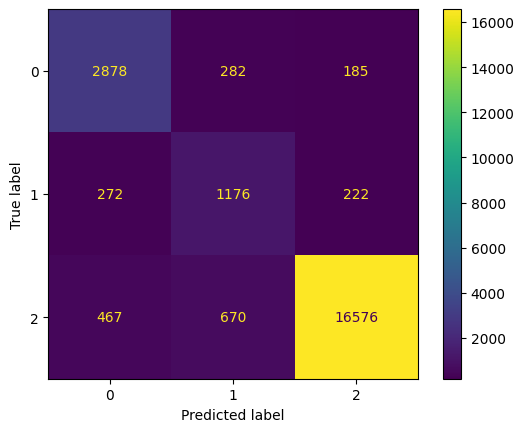

In [68]:
#Métricas
conf_matrix(y_test_final,test_preds_1)

In [69]:
metrics(y_test_final,test_preds_1)
print(f"====")
report(y_test_final,test_preds_1)

Accuracy: 0.9076909538894755
F1 Score: 0.8005154700899381
Precision: 0.7747844902627686
Recall: 0.8334633712314522
====
              precision    recall  f1-score   support

     Clase 0       0.80      0.86      0.83      3345
     Clase 1       0.55      0.70      0.62      1670
     Clase 2       0.98      0.94      0.96     17713

    accuracy                           0.91     22728
   macro avg       0.77      0.83      0.80     22728
weighted avg       0.92      0.91      0.91     22728



### DEEP LEARNING

In [147]:
def load_dl_models_no_attention():

    #LSTM Modelo
    weights_lstm_no_attn_ln=torch.load("ruta_del_archivo_pth_donde_se_almaceno_el_modelo_lstm_no_attn",
                                           weights_only=True,map_location=torch.device("cpu"))
        

    lstm_modelo_no_attn_ln=ModeloLSTM(len_vocab=8000,num_clases=3,emb_dim=300,hidden_size=256,num_layers=2,
                         out_l1_dim=128,out_l2_dim=64,bidirectional=False)
    lstm_modelo_no_attn_ln.load_state_dict(weights_lstm_no_attn_ln)


    #GRU Modelo
    weights_gru_no_attn_ln=torch.load("ruta_del_archivo_pth_donde_se_almaceno_el_modelo_gru_no_attn",
                                           weights_only=True,map_location=torch.device("cpu"))


    gru_modelo_no_attn_ln=ModeloGRU(len_vocab=8000,num_clases=3,emb_dim=300,hidden_size=256,num_layers=2,
                         out_l1_dim=128,out_l2_dim=64,bidirectional=False)
    gru_modelo_no_attn_ln.load_state_dict(weights_gru_no_attn_ln)
    

    return lstm_modelo_no_attn_ln,gru_modelo_no_attn_ln


def load_dl_model_with_Attention():

    #Attention Model (No Query Vector and Layer Norm):
    weights_attn_mod=torch.load("ruta_del_archivo_pth_donde_se_almaceno_el_modelo_gru_with_attn",
                                    weights_only=True,map_location=torch.device("cpu"))     

    modelo_attn_no_query=Modelo_Attention(len_vocab=8000,num_clases=3,emb_dim=300,hidden_size=256,context_vector_attn_size=128,num_layers=2,
                         out_l1_dim=128,out_l2_dim=64,bidirectional=False)
    res=modelo_attn_no_query.load_state_dict(weights_attn_mod)
    

    return modelo_attn_no_query

In [148]:
def load_models():
        #SentencePiece, Attention y LSTM/GRU
        
        #Sentence Piece
        tokenizer_model=smp.SentencePieceProcessor()
        tokenizer_model.load("ruta_del_archivo_model_donde_se_almaceno_el_tokenizador_sentence_piece")

        #Modelos NO attention mechanism
        lstm_modelo_no_attn_ln,gru_modelo_no_attn_ln=load_dl_models_no_attention()

        #Modelo SÍ attention mechanism
        modelo_attn_no_query=load_dl_model_with_Attention()


        return tokenizer_model,modelo_attn_no_query,lstm_modelo_no_attn_ln,gru_modelo_no_attn_ln

### Instanciar GRU + Attention

In [146]:
class Attention(torch.nn.Module):
    def __init__(self,bidirectional,hidden_size_model,context_vector_size):
        super().__init__()
        self.bidirectional=bidirectional
        
        self.U=torch.nn.Linear(in_features=hidden_size_model*bidirectional,out_features=context_vector_size)
        self.V=torch.nn.Linear(in_features=context_vector_size,out_features=1)

        
        
        self.tanh=torch.nn.Tanh()
        self.softmax=torch.nn.Softmax(dim=1)


    def forward(self,query,keys,batch_lengths):

        #Máscaras
        mask=torch.arange(keys.size(1),device=keys.device).unsqueeze(0)
        mask=mask.expand(keys.size(0),keys.size(1))
        value_masks=mask<torch.tensor(batch_lengths,device=keys.device).unsqueeze(1)
        
        
        
        #Key vectors: [batch_size,seq_length,D*h_out], D:bidirectional or not
        #--> will contain a concatenation of the forward and reverse hidden states at each time step in the sequence (PyTorch Source)
        keys_vector=self.U(keys)    #--> AT EATCH time step, forward and reverse hidden states
        

        #Tanh activation function
        tanh=self.tanh(keys_vector)
        


        #Weights attention scores de cada HIDDEN STATE
        v=self.V(tanh).squeeze(2)                                #[batch_size,sequence_length,1] --> [batch_size,sequence_length]
        v_masked=v.masked_fill(~value_masks.to(device),-1e9)
        weights_attention=self.softmax(v_masked).unsqueeze(1)           #[batch_size,1,sequence_length]
        

        context_vector=torch.bmm(weights_attention,keys)    #--> weights_attention [batch_size,1,sequence_length]*keys [batch_size,sequence_length,D*Hout]
                                                                            #--> context_vector: [batch_size,1,D*Hout]
        context_vector_final=context_vector.squeeze(1)   #--> context_vector_final: [batch_size,D*Hout]
        
        
        return context_vector_final
    


class Modelo_Attention(torch.nn.Module):
    def __init__(self,len_vocab,num_clases,emb_dim,hidden_size,context_vector_attn_size,num_layers,out_l1_dim,out_l2_dim,bidirectional:bool):
        super().__init__()
        self.num_emb=len_vocab
        self.bid=2 if bidirectional else 1
        self.embedding_layer=torch.nn.Embedding(num_embeddings=self.num_emb,embedding_dim=emb_dim)
        
        self.gru=torch.nn.GRU(input_size=emb_dim,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,bidirectional=bidirectional)
        
        self.ln1=torch.nn.Linear(in_features=hidden_size*self.bid,out_features=out_l1_dim)
        self.ln2=torch.nn.Linear(in_features=out_l1_dim,out_features=out_l2_dim)
        self.ln3=torch.nn.Linear(in_features=out_l2_dim,out_features=num_clases)
        self.relu=torch.nn.ReLU()
        
        self.dropout=torch.nn.Dropout(p=0.1)
        self.layer_norm1=torch.nn.LayerNorm(out_l1_dim)
        self.layer_norm2=torch.nn.LayerNorm(out_l2_dim)
        
        self.attention=Attention(bidirectional=self.bid,hidden_size_model=hidden_size,context_vector_size=context_vector_attn_size)

    
    def forward(self,data,length_batch):
        x=self.embedding_layer(data) #[num_batch,seq_length,embedding_dim]

        padded_sequence=pack_padded_sequence(input=x,lengths=length_batch,batch_first=True,enforce_sorted=False) ##-->> OJITO
        
        
        #GRU                                                        
        hidden_states_no_padding,final_hidden_state_real=self.gru(padded_sequence) #[num_batch,time_steps,emb_dim],[D*num_layers,batch_size,hidden_size], D:2 if bidirectional, else 1
        
        
        #Pad Packed Sequence para los hidden states y el attention mechanism
        hidden_states_padding,_=pad_packed_sequence(sequence=hidden_states_no_padding,batch_first=True)
        
        
        #Attention
        batch_context_vectors=self.attention(query=final_hidden_state_real,keys=hidden_states_padding,batch_lengths=length_batch)


        #Linear layers
        x=self.relu(self.dropout(self.layer_norm1(self.ln1(batch_context_vectors))))
        x=self.relu(self.dropout(self.layer_norm2(self.ln2(x))))
        x=self.ln3(x)
        
        return x

### Instanciar GRU

In [103]:
class ModeloGRU(torch.nn.Module):
    def __init__(self,len_vocab,num_clases,emb_dim,hidden_size,num_layers,out_l1_dim,out_l2_dim,bidirectional:bool):
        super().__init__()
        self.num_emb=len_vocab
        self.bid=2 if bidirectional else 1
        
        self.embedding_layer=torch.nn.Embedding(num_embeddings=self.num_emb,embedding_dim=emb_dim,padding_idx=0)
        
        self.gru=torch.nn.GRU(input_size=emb_dim,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,bidirectional=bidirectional)
        
        self.ln1=torch.nn.Linear(in_features=hidden_size*self.bid,out_features=out_l1_dim) #--> concatenar en vez de multiplicar las múltiples salidas
        self.ln2=torch.nn.Linear(in_features=out_l1_dim,out_features=out_l2_dim)
        self.ln3=torch.nn.Linear(in_features=out_l2_dim,out_features=num_clases) #num_clases=5
        self.relu=torch.nn.ReLU()
        
        self.dropout=torch.nn.Dropout(p=0.1)
        self.layer_norm_1=torch.nn.LayerNorm(out_l1_dim)
        self.layer_norm_2=torch.nn.LayerNorm(out_l2_dim)


    def forward(self,data,length_batch):
        x=self.embedding_layer(data) #[num_batch,seq_length,embedding_dim]
        
        padded_sequence=pack_padded_sequence(input=x,lengths=length_batch,batch_first=True,enforce_sorted=False) ##-->> OJITO
        
        #GRU                                                        
        hidden_states_no_padding,final_hidden_state_real=self.gru(padded_sequence) #[num_batch,time_steps,emb_dim],[D*num_layers,batch_size,hidden_size], D:2 if bidirectional, else 1

        hidden_states_padding,_=pad_packed_sequence(sequence=hidden_states_no_padding,batch_first=True)  #--> [N,L,D*Hout], [:,:,:mitad] forward, [:,:,mitad:] backward en 't'


        x_rsh,indexes=torch.max(hidden_states_padding,dim=1) #[batch_size,hidden_state]
        
       
        x=self.relu(self.dropout(self.layer_norm_1(self.ln1(x_rsh))))
        x=self.relu(self.dropout(self.layer_norm_2(self.ln2(x))))
        x=self.ln3(x)
        
        return x

### Instanciar LSTM

In [104]:
class ModeloLSTM(torch.nn.Module):
    def __init__(self,len_vocab,num_clases,emb_dim,hidden_size,num_layers,out_l1_dim,out_l2_dim,bidirectional:bool):
        super().__init__()
        self.num_emb=len_vocab
        self.bid=2 if bidirectional else 1
        
        self.embedding_layer=torch.nn.Embedding(num_embeddings=self.num_emb,embedding_dim=emb_dim,padding_idx=0)
        
        self.lstm=torch.nn.LSTM(input_size=emb_dim,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,bidirectional=bidirectional)
        
        self.ln1=torch.nn.Linear(in_features=hidden_size*self.bid,out_features=out_l1_dim) #--> concatenar en vez de multiplicar las múltiples salidas
        self.ln2=torch.nn.Linear(in_features=out_l1_dim,out_features=out_l2_dim)
        self.ln3=torch.nn.Linear(in_features=out_l2_dim,out_features=num_clases) #num_clases=5
        self.relu=torch.nn.ReLU()
        

        self.dropout=torch.nn.Dropout(p=0.1)
        self.layer_norm_1=torch.nn.LayerNorm(out_l1_dim)
        self.layer_norm_2=torch.nn.LayerNorm(out_l2_dim)


    def forward(self,data,length_batch):
        x=self.embedding_layer(data) #[num_batch,seq_length,embedding_dim]
        
        padded_sequence=pack_padded_sequence(input=x,lengths=length_batch,batch_first=True,enforce_sorted=False) ##-->> OJITO
        
        #LSTM
        hidden_states_no_padding,(final_hidden_state_real,final_cell_state)=self.lstm(padded_sequence)
        hidden_states_padding,_=pad_packed_sequence(sequence=hidden_states_no_padding,batch_first=True)  #--> [N,L,D*Hout], [:,:,:mitad] forward, [:,:,mitad:] backward en 't'
        

        x_rsh,indexes=torch.max(hidden_states_padding,dim=1) #[batch_size,hidden_state]
        
    
        x=self.relu(self.dropout(self.layer_norm_1(self.ln1(x_rsh))))
        x=self.relu(self.dropout(self.layer_norm_2(self.ln2(x))))
        x=self.ln3(x)
        
        return x

In [ ]:
#Instanciar los modelos del enfoque Deep Learning
tokenizer,modelo_attn_no_query,lstm_no_attn_ln,gru_no_attn_ln=load_models()

#### Función para evaluar los modelos

In [152]:
def evaluate_model(model,data):
    model.eval()
    y_preds,y_real=[],[]
    with torch.no_grad():
        for idx,(x,y,length_data_batch) in enumerate(data):     
            preds=model(x.to(device),length_data_batch)
            y_preds.append(preds)
            y_real.append(y)

    #Numpy arrays
    y_preds_final,y_real_final=torch.argmax(torch.cat(y_preds,dim=0).squeeze(1).cpu(),dim=1).numpy(),torch.cat(y_real,dim=0).squeeze(1).cpu().numpy()
    
    #Convertir las predicciones a clases binarias en base al threshold
    #y_preds_bin_final=(y_preds_final>threshold).astype(np.float32)

    print(f"y preds final: {y_preds_final.shape}, dtype: {y_preds_final.dtype}")
    print(f"y rela final: {y_real_final.shape}, dtype: {y_real_final.dtype}")
    
    return y_preds_final,y_real_final

In [153]:
y_preds_test,y_real_test=evaluate_model(modelo_attn_no_query.to(device),data=dataloader_test) #Colocar el modelo a evaluar como primer parámetro

y preds final: (22728,), dtype: int64
y rela final: (22728,), dtype: float32


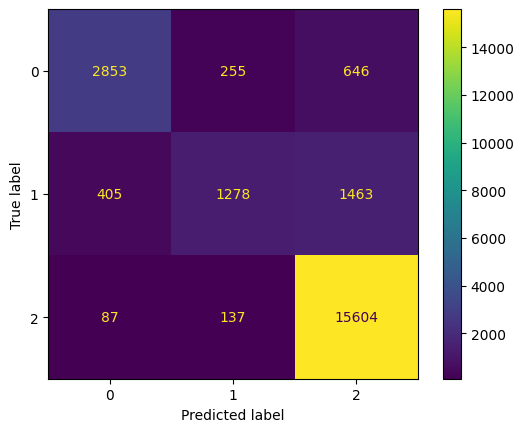

In [155]:
conf_matrix(y_preds_test,y_real_test)

In [156]:
metrics(y_preds_test,y_real_test)
print(f"====")
report(y_preds_test,y_real_test)

Accuracy: 0.8683122140091517
F1 Score: 0.7549831382056538
Precision: 0.8330397219499739
Recall: 0.7173557809152316
====
              precision    recall  f1-score   support

     Clase 0       0.85      0.76      0.80      3754
     Clase 1       0.77      0.41      0.53      3146
     Clase 2       0.88      0.99      0.93     15828

    accuracy                           0.87     22728
   macro avg       0.83      0.72      0.75     22728
weighted avg       0.86      0.87      0.85     22728



----